In [1]:
import torch
import numpy as np
import pandas as pd
from torch import nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleParams, SampleAlpha
from constants import lower_bounds
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

# Plots
colormap = "coolwarm" 
fontsize = 13

# Data
names = {0:"Open LLM Leaderboard v1/v2", 1:"Open LLM Leaderboard v1",2:"Open LLM Leaderboard v2"}
Y_names_tidy = {'gsm8k':'GSM8k','ifeval':'IFEval','hellaswag':'HellaSwag','mmlu':'MMLU','arc':'ARC',
                'truthfulqa':'TruthfulQA','winogrande':'Winogrande','bbh':'BBH','math':'MATH',
                'mmlu-pro':'MMLU-Pro','gpqa':'GPQA','musr':'MuSR'}
eps = 1e-3

# Model specification
Ks = [1,2,3,4,5,6,7,8,9,10,11,12]

# Model fitting
B = 10000
lrs = [.1,.05,.01]
scheduler_factors = [.999,.99]
reps = 5
n_epochs = 20000
random_seed = 42
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def numpy_to_latex_table(
    estimates: np.ndarray,
    std_errors: np.ndarray,
    row_labels: list = None,
    col_names: list = None,
    float_format: str = "%.2f"
) -> str:
    r"""
    Generate a LaTeX table from two 2D NumPy arrays: one of estimates and one of standard errors.
    The standard errors are shown in parentheses below their corresponding estimates.
    Uses \multirow to centralize row labels over the estimate/SE pair.
    Optionally includes column names as a header row.

    Parameters:
    - estimates (np.ndarray): 2D array of point estimates.
    - std_errors (np.ndarray): 2D array of standard errors, same shape as estimates.
    - row_labels (list, optional): List of labels (str) for each row of estimates. Length must match number of rows.
                                   If provided, each label is placed using \multirow{2}{*}{label}.
    - col_names (list, optional): List of column header names (str) for each estimate column. Length must match number of columns.
    - float_format (str): Format string for floats, default is two decimal places.

    Returns:
    - str: A string containing the LaTeX code for the table. Requires \usepackage{multirow} and \usepackage{booktabs}.
    """
    if estimates.shape != std_errors.shape:
        raise ValueError("Estimates and standard errors must have the same shape.")

    n_rows, n_cols = estimates.shape

    if row_labels is not None:
        if len(row_labels) != n_rows:
            raise ValueError("Length of row_labels must match number of rows in estimates.")
    if col_names is not None:
        if len(col_names) != n_cols:
            raise ValueError("Length of col_names must match number of columns in estimates.")

    # Begin LaTeX table
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"% Requires \usepackage{booktabs} and \usepackage{multirow}")

    # Build column format: one 'c' for each column, plus one 'c' for row_labels if provided
    if row_labels is not None:
        col_format = "c " + " ".join(["c"] * n_cols)
    else:
        col_format = " ".join(["c"] * n_cols)
    latex.append(r"\begin{tabular}{" + col_format + r"}")
    latex.append(r"\toprule")

    # Header row if column names are provided
    if col_names is not None:
        if row_labels is not None:
            header = " & " + " & ".join(col_names) + r" \\"
        else:
            header = " & ".join(col_names) + r" \\"
        latex.append(header)
        latex.append(r"\midrule")

    for i in range(n_rows):
        # Estimate row with multirow label (if provided)
        if row_labels is not None:
            est_line = (
                r"\multirow{2}{*}{" + row_labels[i] + "} & " +
                " & ".join(float_format % est for est in estimates[i, :]) +
                r" \\"
            )
        else:
            est_line = " & ".join(float_format % est for est in estimates[i, :]) + r" \\"
        latex.append(est_line)

        # Std error row (blank first cell if label provided)
        if row_labels is not None:
            se_line = " & " + " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        else:
            se_line = " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        latex.append(se_line)

        if i < n_rows - 1:
            latex.append(r"\midrule")

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{Insert your caption here.}")
    latex.append(r"\label{tab:insert_label_here}")
    latex.append(r"\end{table}")

    return "\n".join(latex)

/Users/maiapolo/Desktop/statistical-scaling-law/scaling_law/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [2]:
dfs = {}
dfs[1] = pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1)
dfs[2] = pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1)
dfs[0] = pd.merge(dfs[1], dfs[2], on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')
dfs[0].shape, dfs[1].shape, dfs[2].shape

((286, 17), (168, 11), (216, 11))

In [11]:
for i in range(3):
    print(i,len(set(dfs[i].model)),len(set(dfs[i].family)))

0 285 170
1 168 75
2 215 146


In [3]:
Y_names = {}
Y_names[0] = ['math','ifeval','hellaswag','bbh','mmlu-pro','mmlu','arc','truthfulqa','gsm8k','winogrande','gpqa','musr']
Y_names[1] = ['gsm8k','truthfulqa','hellaswag','mmlu','arc','winogrande']
Y_names[2] = ['math','ifeval','bbh','mmlu-pro','gpqa','musr']

In [4]:
Ys = {}
Xs = {}
Ds = {}
Cs = {}
mus = {}
stds = {}

for j in Y_names.keys():
    Ys[j] = np.array(dfs[j].loc[:,Y_names[j]])
    Ys[j] = np.clip(Ys[j], a_min=eps, a_max=1-eps)
        
    X = np.log(np.array(dfs[j].loc[:,['size','tokens']]))
    Xs[j] = np.hstack((X,(X[:,0]*X[:,1])[:,None]))
    mus[j] = Xs[j].mean(0)
    stds[j] = Xs[j].std(0)
    Xs[j] = (Xs[j]-mus[j])/stds[j]
    
    Ds[j] = np.array(pd.get_dummies(dfs[j].family)).astype(int)

    Cs[j] = np.array([lower_bounds[s] for s in Y_names[j]]).reshape((1,-1))

## Model fitting

In [ ]:
for j in tqdm(Y_names.keys()):#
    models = {}
    for k in Ks:
        models[k] = ScalingLaw(k)
        models[k].fit(Xs[j],
                      Ys[j],
                      Ds[j],
                      Cs[j],
                      B = B,
                      lrs = lrs,
                      scheduler_factors = scheduler_factors,
                      reps = reps,
                      n_epochs = n_epochs,    
                      verbose = False,
                      device = device)
        
        np.save(f"models/models_{j}.npy",models)

## Plots

In [14]:
models = {j: np.load(f"models/models_{j}.npy", allow_pickle=True).item() for j in range(3)}
models[0] = np.load(f"models/models_0_v2.npy", allow_pickle=True).item()

### AIC

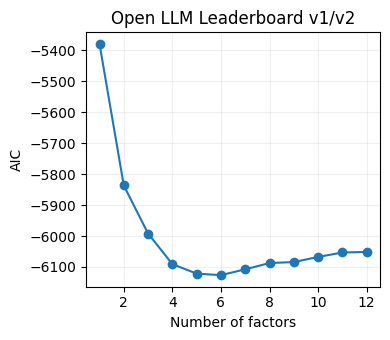

In [15]:
aic = [m.aic for m in models[0].values()]

fig, axes = plt.subplots(1, 1, figsize=(4, 3.5))

axes.plot(list(range(1,13)), aic, marker='o')
axes.set_title(names[0])
axes.set_xlabel('Number of factors')
axes.set_ylabel('AIC')
axes.grid(True,alpha=.2)

plt.tight_layout()
plt.savefig(f'plots/aic.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

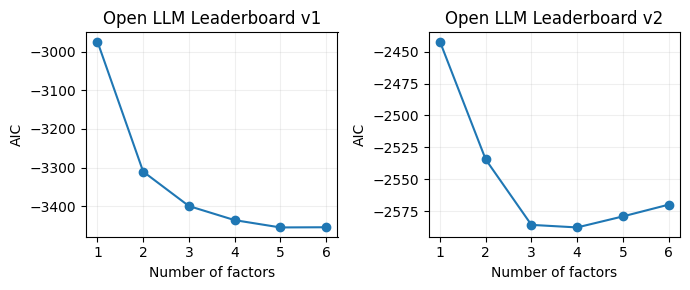

In [16]:
aic1 = [m.aic for m in models[1].values()]
aic2 = [m.aic for m in models[2].values()]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].plot(list(range(1,7)), aic1, marker='o')
axes[0].set_title(names[1])
axes[0].set_xlabel('Number of factors')
axes[0].set_ylabel('AIC')
axes[0].grid(True,alpha=.2)

axes[1].plot(list(range(1,7)), aic2, marker='o')
axes[1].set_title(names[2])
axes[1].set_xlabel('Number of factors')
axes[1].set_ylabel('AIC')
axes[1].grid(True,alpha=.2)

plt.tight_layout()
plt.savefig(f'plots/aic2.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Correlations and loadings

In [17]:
K_opt = {0:4,
         1:4,
         2:3}

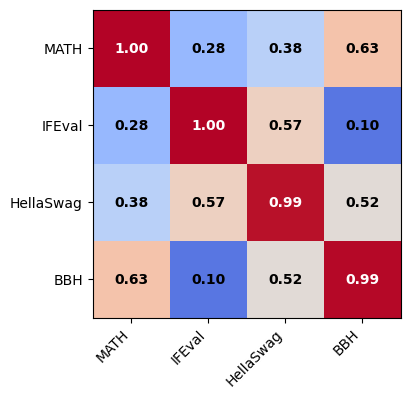

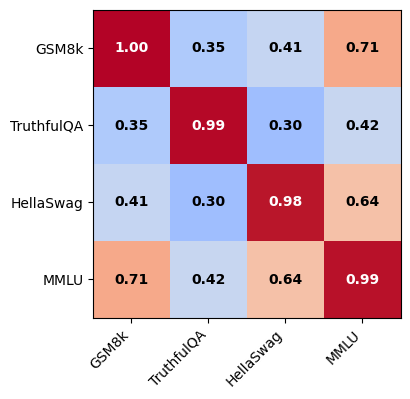

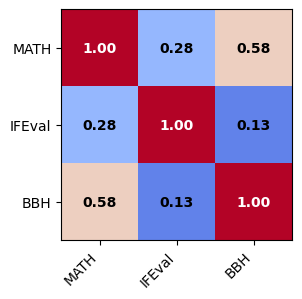

In [18]:
vmin=0
vmax=1
for j in Y_names.keys():

    k = K_opt[j]
    d = k
    model = models[j][k]
    Sigma = model.sigma
    factor_labels=[Y_names_tidy[s] for s in Y_names[j]][:k]
    
    plt.figure(figsize=(d,d))  # Set the figure size (width, height) in inches
    plt.imshow(Sigma, cmap=colormap, vmin=vmin, vmax=vmax)
    plt.xticks(np.arange(d), labels=factor_labels, rotation=45, ha="right")  # Set the x-tick labels
    plt.yticks(np.arange(d), labels=factor_labels, rotation=0, ha="right")  # Set the y-tick labels
    
    threshold = .8
    for i in range(len(Sigma)):
        for jj in range(len(Sigma.T)):
            value = Sigma[i, jj]
            color = "black" if value < threshold else "white"  # Conditional color
            text = plt.text(jj, i, f'{value:.2f}', size=10, ha="center", va="center", color=color, weight='bold')#
    
    plt.savefig(f'plots/skills-correlation_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
    plt.show()

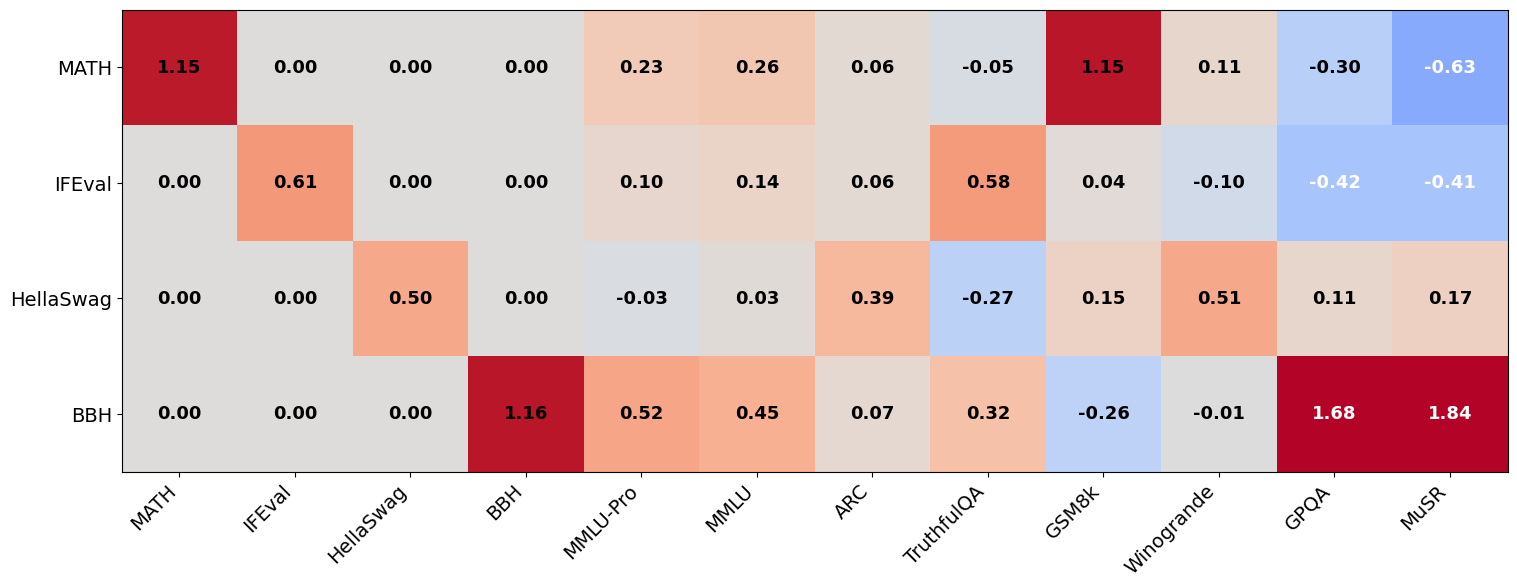

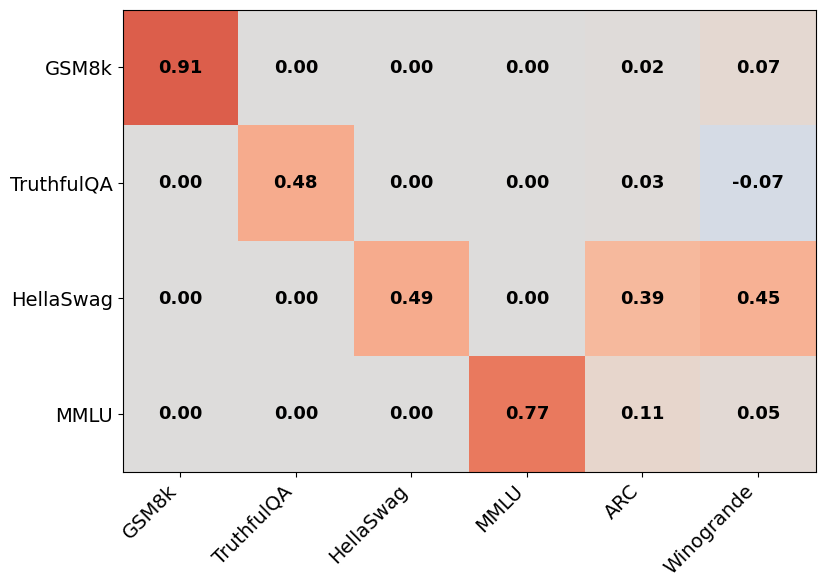

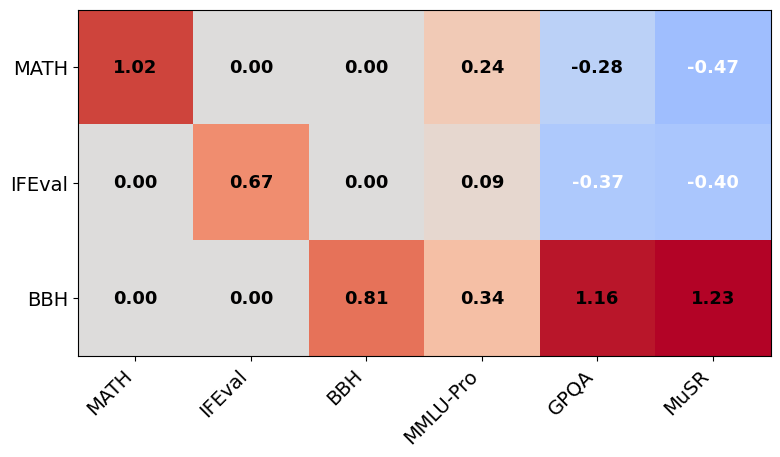

In [19]:
vmin=-1.2#None
vmax=1.2#None

for j in Y_names.keys():

    k = K_opt[j]
    model = models[j][k]
    L_rot = model.lambd
    
    plt.figure(figsize=((10/6)*L_rot.shape[1], (6/4)*k))  # Set the figure size (width, height) in inches
    plt.imshow(L_rot, cmap=colormap, vmin=vmin, vmax=vmax)
    plt.xticks(np.arange(len(Y_names[j])), labels=[Y_names_tidy[s] for s in Y_names[j]], size=fontsize+1, rotation=45, ha="right")  # Set the x-tick labels
    plt.yticks(np.arange(k), labels=[Y_names_tidy[s] for s in Y_names[j]][:k], size=fontsize+1, rotation=0, ha="right")  # Set the y-tick labels
    
    inter = [-.3,1.6]
    for i in range(len(L_rot)):
        for jj in range(len(L_rot.T)):
            value = L_rot[i, jj]
            color = "black" if value > inter[0] and  value < inter[1] else "white"  # Conditional color
            text = plt.text(jj, i, f'{value:.2f}', size=fontsize, ha="center", va="center", color=color, weight='bold')#

    plt.savefig(f'plots/loadings_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
    plt.show()

## Confidence intervals for beta

In [ ]:
Ss = {}
for j in tqdm(Y_names.keys()):
    Ss[j] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], models[j], K_opt[j])
    np.save("data/stes.npy",Ss)

  0%|          | 0/3 [00:00<?, ?it/s]


KeyboardInterrupt



In [20]:
Ss = np.load("data/stes.npy", allow_pickle=True).item()

In [21]:
labels = ['log(s)', 'log(t)', 'log(s)log(t)']

In [22]:
for j in range(3):
    print("\n\n")
    print(numpy_to_latex_table(models[j][K_opt[j]].beta/stds[j][:,None],
                         Ss[j][0][1]['beta_ste']/stds[j][:,None], float_format="%.3f", row_labels=labels, col_names=[f"Factor {f+1}" for f in range(K_opt[j])]))




\begin{table}[ht]
\centering
% Requires \usepackage{booktabs} and \usepackage{multirow}
\begin{tabular}{c c c c c}
\toprule
 & Factor 1 & Factor 2 & Factor 3 & Factor 4 \\
\midrule
\multirow{2}{*}{log(s)} & 0.432 & 0.190 & 0.840 & 0.656 \\
 & (0.065) & (0.054) & (0.055) & (0.079) \\
\midrule
\multirow{2}{*}{log(t)} & 0.774 & 0.324 & 0.384 & 0.445 \\
 & (0.101) & (0.087) & (0.085) & (0.115) \\
\midrule
\multirow{2}{*}{log(s)log(t)} & 0.026 & 0.154 & -0.039 & 0.010 \\
 & (0.032) & (0.034) & (0.016) & (0.041) \\
\bottomrule
\end{tabular}
\caption{Insert your caption here.}
\label{tab:insert_label_here}
\end{table}



\begin{table}[ht]
\centering
% Requires \usepackage{booktabs} and \usepackage{multirow}
\begin{tabular}{c c c c c}
\toprule
 & Factor 1 & Factor 2 & Factor 3 & Factor 4 \\
\midrule
\multirow{2}{*}{log(s)} & 0.449 & 0.082 & 0.865 & 0.642 \\
 & (0.074) & (0.064) & (0.065) & (0.101) \\
\midrule
\multirow{2}{*}{log(t)} & 0.889 & 0.253 & 0.389 & 0.801 \\
 & (0.148) & (0.149) & 

## Family comparison

In [23]:
j = 0
K = K_opt[j]

In [24]:
cov = np.load("data/stes.npy", allow_pickle=True).item()
cov = cov[j][0][0]['V']

beta = models[j][K].beta
b = models[j][K].b
phi = models[j][K].phi
lambd1, lambd2 = np.diag(models[j][K].lambd[:,:K]), models[j][K].lambd[:,K:]
sigma = models[j][K].sigma

In [25]:
family_names = np.array(pd.get_dummies(dfs[j].family).columns)

f1='yi-1.5'
f2='yi-1.5-chat'
fs = [np.argmax(family_names==f1), np.argmax(family_names==f2)]
fs

[np.int64(164), np.int64(165)]

In [57]:
alphas = {}

for fam_number in fs:
    betas, bs, phis, lambds, sigmas = SampleParams(beta, b, phi, lambd1, lambd2, sigma, cov)
    
    alphas[fam_number] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(SampleAlpha)(i, betas, lambds, bs, phis, sigmas, Ds[j], fam_number, Xs[j], Ys[j], Cs[j], K,
                              n_samples=1000, random_seed=fam_number)
        for i in range(len(betas))
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:  4.4min remaining:  4.7min
[Parallel(n_jobs=-1)]: Done  59 out of 100 | elapsed:  4.4min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  70 out of 100 | elapsed:  4.9min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  81 out of 100 | elapsed:  4.9min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  92 out of 100 | elapsed:  4.9min remaining:   25.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.0mi

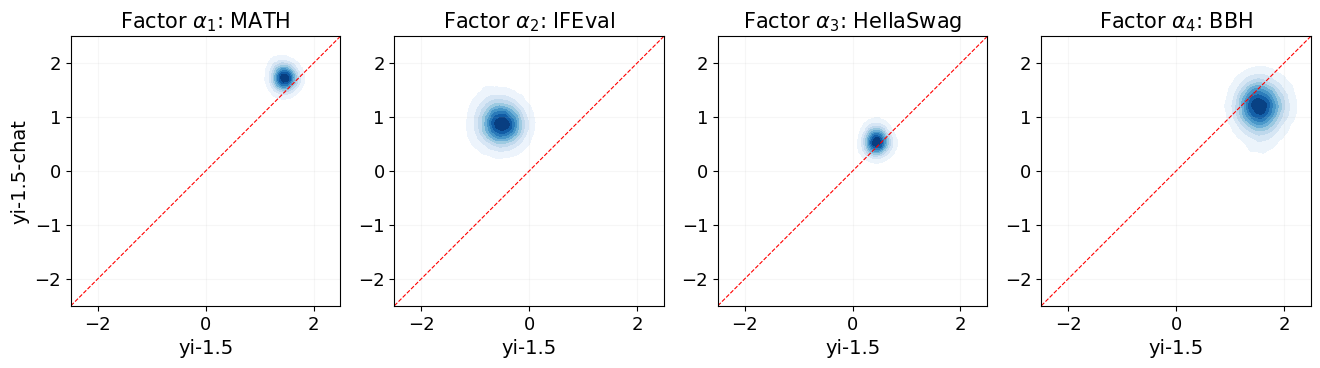

In [69]:
min_val = -2.5
max_val = 2.5

num_plots = K_opt[j]

# Create a row of subplots with shared tick positions
fig, axes = plt.subplots(1, num_plots, figsize=(4*num_plots, 3.5), 
                         sharex=True, sharey=True, squeeze=False)
axes = axes.flatten()  # Ensure we have a 1D array of axes

for k in range(num_plots):
    A = np.hstack((
        np.vstack(alphas[fs[0]])[:, k][:, None],
        np.vstack(alphas[fs[1]])[:, k][:, None]
    ))
    ax = axes[k]
    sns.kdeplot(x=A[:, 0], y=A[:, 1], cmap="Blues", fill=True, ax=ax)
    
    # Red dashed line
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=.8)
    
    # Set axis labels and title
    ax.set_xlabel(f"{f1}", fontsize=fontsize+1)
    ax.set_ylabel(f"{f2}", fontsize=fontsize+1)
    ax.set_title(f'Factor $\\alpha_{{{k+1}}}$: {[Y_names_tidy[s] for s in Y_names[j]][:K_opt[j]][k]}', 
                 fontsize=fontsize+2)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # Ensure tick labels are visible on each subplot
    ax.tick_params(axis='x', labelsize=fontsize, labelbottom=True)
    ax.tick_params(axis='y', labelsize=fontsize, labelleft=True)
    ax.grid(alpha=0.1)

# Adjust horizontal spacing between plots
plt.subplots_adjust(wspace=0.2)
plt.savefig(f'plots/comparing_factors_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Prediction intervals

In [28]:
j = 0
K = K_opt[j]

In [29]:
test_models = {'meta-llama-3':['meta-llama-3-70b', 'meta-llama-3-70b-instruct'],
               'qwen2':['qwen2-72b'],
               'yi-1.5':['yi-1.5-34b', 'yi-1.5-34b-chat'],
               'olmo':['olmo-7b']}
delete_models = {'meta-llama-3':['calme-2.2-llama3-70b',
 'calme-2.3-llama3-70b',
 'calme-2.4-llama3-70b',
 'dolphin-2.9.1-llama-3-70b',
 'higgs-llama-3-70b',
 'llama-3-70b-instruct-v0.1',
 'llama-3-sauerkrautlm-70b-instruct',
 'llama3-openbiollm-70b',
 'meta-llama-3-70b',
 'meta-llama-3-70b-instruct'],
 'qwen2':['calme-2.1-qwen2-72b',
 'calme-2.2-qwen2-72b',
 'calme-2.3-qwen2-72b',
 'dolphin-2.9.2-qwen2-72b',
 'magnum-72b-v1',
 'magnum-v1-72b',
 'magnum-v2-72b',
 'orca_mini_v7_72b',
 'qwen2-72b',
 'qwen2-72b-instruct'],
 'yi-1.5':['blossom-v5.1-34b',
 'dolphin-2.9.1-yi-1.5-34b',
 'yi-1.5-34b',
 'yi-1.5-34b-chat'],
 'olmo':['olmo-7b']}

In [ ]:
pred_models = {}
for fam in test_models.keys():
    train_idx = [m not in delete_models[fam] for m in dfs[j].model]
    
    pred_models[fam] = ScalingLaw(K)
    pred_models[fam].fit(Xs[j][train_idx],
                    Ys[j][train_idx],
                    Ds[j][train_idx],
                    Cs[j],
                    B = B,
                    lrs = lrs,
                    scheduler_factors = scheduler_factors,
                    reps = reps,
                    n_epochs = n_epochs,    
                    verbose = False,
                    device = device)
        
    np.save(f"models/pred_models.npy",pred_models)

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/5 [00:00<?, ?it/s]

/home/skunk/miniconda3/envs/arena/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Exception ignored in: <function tqdm.__del__ at 0x75591c1a6200>
Traceback (most recent call last):
  File "/home/skunk/miniconda3/envs/arena/lib/python3.12/site-packages/tqdm/std.py", line 1147, in __del__
    def __del__(self):

KeyboardInterrupt: 


In [30]:
pred_models = np.load(f"models/pred_models.npy", allow_pickle=True).item()

In [ ]:
pred_Ss = {}
j=0
for fam in tqdm(test_models.keys()):
    pred_Ss[fam] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], pred_models[fam], K)
    np.save("data/pred_stes.npy",pred_Ss)

In [32]:
pred_Ss = np.load("data/pred_stes.npy", allow_pickle=True).item()

In [33]:
test_models = {'meta-llama-3':['meta-llama-3-70b', 'meta-llama-3-70b-instruct'],
               'qwen2':['qwen2-72b'],
               'yi-1.5':['yi-1.5-34b', 'yi-1.5-34b-chat'],
               'olmo':['olmo-7b']}
decode_fam = {'meta-llama-3':'meta-llama-3',
              'meta-llama-3-instruct':'meta-llama-3',
              'qwen2':'qwen2',
              'yi-1.5':'yi-1.5',
              'yi-1.5-chat':'yi-1.5',
              'olmo':'olmo'}

In [34]:
family_names = np.array(pd.get_dummies(dfs[j].family).columns)

alphas, betas, bs, phis, lambds, sigmas = {}, {}, {}, {}, {}, {}

for llm in tqdm(np.hstack(list(test_models.values())).tolist()):
    llm_number = np.argmax(np.array(dfs[j].model)==llm)
    fam = dfs[j].iloc[llm_number].family
    fam_number = np.argmax(family_names==fam)
    
    cov = pred_Ss[decode_fam[fam]][0][0]['V']
    beta = pred_models[decode_fam[fam]].beta
    b = pred_models[decode_fam[fam]].b
    phi = pred_models[decode_fam[fam]].phi
    lambd1, lambd2 = np.diag(pred_models[decode_fam[fam]].lambd[:,:K]), pred_models[decode_fam[fam]].lambd[:,K:]
    sigma = pred_models[decode_fam[fam]].sigma
    
    betas[fam], bs[fam], phis[fam], lambds[fam], sigmas[fam] = SampleParams(beta, b, phi, lambd1, lambd2, sigma, cov)
        
    alphas[fam] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(SampleAlpha)(i, betas[fam], lambds[fam], bs[fam], phis[fam], sigmas[fam], Ds[j], fam_number, Xs[j], Ys[j], Cs[j], K,
                              n_samples=1, random_seed=fam_number)
        for i in range(len(betas[fam]))
    )

  0%|          | 0/6 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done  96 out of 100 | elapsed:   20.4s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.4s
[Parallel(n_jo

In [35]:
sigmoid = torch.sigmoid
from torch.distributions import Beta

In [36]:
x_grid = np.linspace(.5,80,25)
m=1000

In [37]:
perc = {}
perc_grid = {}
XX = {}
YY = {}

for llm in tqdm(np.hstack(list(test_models.values())).tolist()):
    llm_number = np.argmax(np.array(dfs[j].model)==llm)
    fam = dfs[j].iloc[llm_number].family
    fam_number = np.argmax(family_names==fam)
    assert fam_number == np.argmax(Ds[j][llm_number])
    
    X = np.array(dfs[j].loc[:,['size','tokens']])[llm_number]
    Y = torch.tensor(Ys[j][llm_number])
    C = torch.tensor(Cs[j])
    D = torch.tensor(Ds[j])
    
    X_grid = x_grid[:,None]
    X_grid = np.log(np.hstack((X_grid,np.array(X_grid.shape[0]*[X[1]])[:,None])))
    X_grid = np.hstack((X_grid,(X_grid[:,0]*X_grid[:,1])[:,None]))
    X_grid = torch.tensor((X_grid-mus[j])/stds[j])
    
    X = np.log(X)
    X = np.hstack((X[None,:],(X[None,:][:,0]*X[None,:][:,1])[:,None]))
    X = torch.tensor((X-mus[j])/stds[j])

    XX[llm] = X.numpy()
    YY[llm] = Y.numpy()
    
    samples = []
    for t in range(len(betas[fam])):
        beta = torch.tensor(betas[fam][t])
        b = torch.tensor(bs[fam][t])
        phi = torch.tensor(phis[fam][t])
        lambd = torch.tensor(lambds[fam][t])
        alpha = torch.tensor(alphas[fam][t])
        mu = C+(1-C)*sigmoid(torch.clamp((X@beta+alpha)@lambd+b, min=-4.5, max=4.5))
        beta_dist = Beta(phi*mu, phi*(1-mu))
        samples.append(beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy())
    samples = np.vstack(samples)
    
    samples_grid = []
    for x in X_grid[:,None]:
        samples_grid.append([])
        for t in range(len(betas[fam])):
            beta = torch.tensor(betas[fam][t])
            b = torch.tensor(bs[fam][t])
            phi = torch.tensor(phis[fam][t])
            lambd = torch.tensor(lambds[fam][t])
            alpha = torch.tensor(alphas[fam][t])
            mu = C+(1-C)*sigmoid(torch.clamp((x@beta+alpha)@lambd+b, min=-4.5, max=4.5))
            beta_dist = Beta(phi*mu, phi*(1-mu))
            samples_grid[-1].append(beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy())
        samples_grid[-1] = np.vstack(samples_grid[-1])
    samples_grid = np.array(samples_grid)
    
    perc[llm] = np.percentile(samples, q=[2.5,97.5,50], axis=0)
    perc_grid[llm] = np.percentile(samples_grid, q=[2.5,97.5,50], axis=1)

  0%|          | 0/6 [00:00<?, ?it/s]

In [46]:
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_scaling_panels(
    Y_names, j, test_models, x_grid, perc_grid, mus, stds, XX, YY,
    *,
    ncols=3,
    figsize=(10, 12),
    dpi=300,
    out_path="scaling_panels.png",
    ylims=(0.0, 1.0),
    left_ylabel="score",
    bottom_xlabel=r"# weights ($10^9$)",
    title_size=11,
    label_size=10,
    tick_size=9,
    legend_ncols=3,
    label_map=None,          # e.g., {"yi-1.5-34b-chat":"yi-1.5-34b-chat"}
    linestyle_map=None       # e.g., {"qwen2-72b":"--","yi-1.5-34b": "-","yi-1.5-34b-chat": ":"}
):
    """
    Creates a K-panel figure (K = len(Y_names[j])) with one subplot per task.
    For each model m, it plots:
      - median curve: perc_grid[m][2][:, k]
      - shaded band:  perc_grid[m][0][:, k] .. perc_grid[m][1][:, k]
      - scatter:      (exp(mus[j] + stds[j] * XX[m]), YY[m][k])

    Colors are consistent per model across all artists.
    """
    if label_map is None:
        label_map = {}
    if linestyle_map is None:
        linestyle_map = {}

    # ---- Collect models in your existing order (no duplicates) ----
    model_list = []
    for v in test_models.values():
        model_list.extend(v)
    models = list(dict.fromkeys(model_list))

    # ---- Assign stable colors (prefer tab10 if available; fallback to C0..C9) ----
    try:
        tab10 = mpl.colormaps["tab10"]          # Matplotlib ≥ 3.6
        colors = {m: tab10(i % 10) for i, m in enumerate(models)}
    except Exception:
        colors = {m: f"C{i % 10}" for i, m in enumerate(models)}

    # ---- Build the subplot grid ----
    n_tasks = len(Y_names[j])
    nrows = math.ceil(n_tasks / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for k in range(n_tasks):
        ax = axes[k]
        ax.set_ylim(*ylims)
        ax.set_title(Y_names[j][k], fontsize=title_size)

        for m in models:
            col = colors[m]
            ls = linestyle_map.get(m, "--")

            # Curves and band
            y_med = np.asarray(perc_grid[m][2][:, k])
            y_lo  = np.asarray(perc_grid[m][0][:, k])
            y_hi  = np.asarray(perc_grid[m][1][:, k])

            ax.plot(x_grid, y_med, linestyle=ls, linewidth=1, color=col, label=label_map.get(m, m))
            ax.fill_between(x_grid, y_lo, y_hi, color=col, alpha=0.1, linewidth=0)

            # Scatter point at evaluated size
            x_scat = float(np.ravel(np.exp(mus[j] + stds[j] * XX[m]))[0])
            y_scat = float(YY[m][k])
            ax.scatter(x_scat, y_scat, s=28, color=col, edgecolor="none", zorder=3)

        # Only left column gets y-label; only bottom row gets x-label
        row_idx = k // ncols
        col_idx = k % ncols
        if col_idx == 0:
            ax.set_ylabel(left_ylabel, fontsize=label_size)
        else:
            ax.tick_params(axis="y", labelleft=False)

        if row_idx == nrows - 1:
            ax.set_xlabel(bottom_xlabel, fontsize=label_size)
        else:
            ax.tick_params(axis="x", labelbottom=False)

        ax.tick_params(labelsize=tick_size)

    # Hide any unused axes
    for k in range(n_tasks, len(axes)):
        axes[k].axis("off")

    # ---- Shared legend (one entry per model) ----
    legend_handles = [
        Line2D([0], [0],
               color=colors[m],
               linestyle=linestyle_map.get(m, "-"),
               linewidth=2,
               label=label_map.get(m, m))
        for m in models
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(legend_ncols, len(models)),
        fontsize=label_size,
        bbox_to_anchor=(0.5, -0.01)
    )

    # Room for legend + save
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved figure to: {out_path}")


# ---- Usage (uncomment once your variables exist) ----
plot_scaling_panels(
     {j: [Y_names_tidy[s] for s in Y_names[j]]}, j, test_models, x_grid, perc_grid, mus, stds, XX, YY,
     out_path="plots/scaling_panels.png",
     # Optional styling:
     # label_map={"qwen2-72b":"qwen2-72b", "yi-1.5-34b":"yi-1.5-34b", "yi-1.5-34b-chat":"yi-1.5-34b-chat"},
     # linestyle_map={"qwen2-72b":"--", "yi-1.5-34b":"-", "yi-1.5-34b-chat":":"},
)


Saved figure to: plots/scaling_panels.png


## Optimal scaling

In [437]:
import numpy as np

def make_joint_latex_table(
    t1, t2, t3, t4,
    group_names=[Y_names_tidy[y] for y in Y_names[j][:K_opt[j]]],
    caption="Optimal allocation across skills for various compute budgets.",
    label="tab:opt_full",
    flops_header=r"\textbf{FLOPs (1e19)",
    inner_headers=(r"\textbf{Params (B)}", r"\textbf{Tokens (T)}"),
    decimals=2,
):
    """
    Merge four (n,3) arrays [FLOPs, Params, Tokens] into one LaTeX table:
    1 shared FLOPs column + 2 columns per table = 9 columns total.
    """

    tables = [np.asarray(t, dtype=float) for t in (t1, t2, t3, t4)]
    nrows = tables[0].shape[0]

    # Validate shapes
    for i, t in enumerate(tables, 1):
        if t.ndim != 2 or t.shape[1] != 3:
            raise ValueError(f"Table {i} must have shape (n, 3): [FLOPs, Params, Tokens].")
        if t.shape[0] != nrows:
            raise ValueError("All tables must have the same number of rows (same FLOPs grid).")

    # Check FLOPs column alignment
    base_flops = tables[0][:, 0]
    for i in range(1, 4):
        if not np.allclose(base_flops, tables[i][:, 0], rtol=0, atol=1e-9):
            raise ValueError("First column (FLOPs) must match across all four tables.")

    # Formatting helpers
    fmt = f"{{:.{decimals}f}}".format

    def _tex_escape(s: str) -> str:
        return (s.replace("&", r"\&")
                 .replace("%", r"\%")
                 .replace("$", r"\$")
                 .replace("#", r"\#")
                 .replace("_", r"\_")
                 .replace("{", r"\{")
                 .replace("}", r"\}")
                 .replace("~", r"\textasciitilde{}")
                 .replace("^", r"\textasciicircum{}"))

    gnames = [_tex_escape(str(x)) for x in group_names]
    ih1, ih2 = inner_headers

    # Column alignment: c | cc | cc | cc | cc
    align = "c|" + "cc|" * 3 + "cc"

    # Build header lines (use only plain r-strings when no interpolation is needed)
    group_parts = []
    for k, name in enumerate(gnames):
        bar = "|" if k < len(gnames) - 1 else ""
        group_parts.append(rf"\multicolumn{{2}}{{c{bar}}}{{\textbf{{{name}}}}}")
    header_top = rf"{flops_header} & " + " & ".join(group_parts) + r" \\"
    header_sub = " & " + " & ".join([rf"{ih1} & {ih2}"] * 4) + r" \\"

    # Body rows
    body_lines = []
    for r in range(nrows):
        row = [fmt(base_flops[r])]
        for t in tables:
            row.append(fmt(t[r, 1]))  # Params
            row.append(fmt(t[r, 2]))  # Tokens
        body_lines.append(" & ".join(row) + r" \\")

    # Assemble LaTeX table
    latex = [
        r"\begin{table}[h!]",
        r"\centering",
        r"\footnotesize",
        rf"\begin{{tabular}}{{{align}}}",  # <-- doubled braces around 'tabular'
        r"\toprule",
        header_top,
        header_sub,
        r"\midrule",
        *body_lines,
        r"\bottomrule",
        r"\end{tabular}",
        rf"\caption{{{_tex_escape(caption)}}}",
        rf"\label{{{_tex_escape(label)}}}",
        r"\end{table}",
    ]
    return "\n".join(latex)

In [436]:
j=0

In [386]:
X = stds[j]*Xs[j]+mus[j]

In [399]:
Cs = [X.min(0)[:-1].sum(-1),X.max(0)[:-1].sum(-1)]
Cs = np.linspace(Cs[0], Cs[1], 10)

In [423]:
argmaxs = {}
for k in range(K_opt[j]):
    argmaxs[k] = []
    beta = models[j][K_opt[j]].beta[:,k]/stds[j]
    for c in Cs:
        
        def g(u,c):
            return -beta[2]*u**2 + (beta[0]-beta[1]+beta[2]*c)*u
        
        U = np.linspace(max(c-X.max(0)[1],X.min(0)[0]), min(c-X.min(0)[1],X.max(0)[0]), 1000)
        assert U[0]<=U[1]
        argmax_u = U[np.argmax([g(u,c) for u in U])]
        argmax_v = c - argmax_u
    
        argmaxs[k].append([np.exp(argmax_u), np.exp(argmax_v)])
    argmaxs[k] = np.array(argmaxs[k])
    argmaxs[k] = np.hstack((100*6*np.prod(argmaxs[k], -1)[:,None], argmaxs[k]))

In [438]:
print(make_joint_latex_table(argmaxs[0], argmaxs[1], argmaxs[2], argmaxs[3]))

\begin{table}[h!]
\centering
\footnotesize
\begin{tabular}{c|cc|cc|cc|cc}
\toprule
\textbf{FLOPs (1e19) & \multicolumn{2}{c|}{\textbf{MATH}} & \multicolumn{2}{c|}{\textbf{IFEval}} & \multicolumn{2}{c|}{\textbf{HellaSwag}} & \multicolumn{2}{c}{\textbf{BBH}} \\
 & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} \\
\midrule
6.30 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 \\
25.15 & 0.07 & 0.60 & 0.13 & 0.32 & 0.28 & 0.15 & 0.28 & 0.15 \\
100.37 & 0.07 & 2.39 & 0.26 & 0.63 & 1.12 & 0.15 & 1.12 & 0.15 \\
400.62 & 0.07 & 9.54 & 0.53 & 1.27 & 4.45 & 0.15 & 4.45 & 0.15 \\
1599.05 & 0.18 & 15.00 & 1.06 & 2.52 & 17.77 & 0.15 & 17.77 & 0.15 \\
6382.53 & 0.71 & 15.00 & 2.10 & 5.05 & 70.92 & 0.15 & 70.92 & 0.15 \\
25475.55 & 2.83 & 15.00 & 4.22 & 10.06 & 180.00 & 0.24 & 180.00 & 0.24 \\
101684.33 & 11.30 & 15.00 & 11.30 & 15.00 & 180.00 & 0.94 & 180.00 & 0.94 \\